# 1. Equations of Motion
This notebook derives the equations of motion for a two-link inverted pendulum using the Lagrangian formulation and verifies the result symbolically.

In [1]:
%load_ext autoreload

from sympy import symbols, cos, simplify, init_printing, sin
from sympy.physics.mechanics import dynamicsymbols, LagrangesMethod, ReferenceFrame

init_printing()
# --- Setting up Lagrangian ---
alpha, phi = dynamicsymbols('alpha phi')
alpha_dot, phi_dot= dynamicsymbols('alpha phi', 1)

J_1, J_2, J_12 = symbols('J_alpha J_phi J_alpha_phi')
mu_1, mu_2 = symbols('eta_alpha eta_phi')
d = symbols('d') 

# Input torque
tau_alpha = dynamicsymbols('tau_alpha')

T = alpha_dot**2 * J_1 + phi_dot**2 * J_2 + alpha_dot * phi_dot * cos(alpha - phi) * J_12
U = cos(alpha) * mu_1 + cos(phi) * mu_2

L = T - U

N = ReferenceFrame('N')
A = ReferenceFrame('A')
B = ReferenceFrame('B')

A.orient(N, "Axis", (alpha, N.z))
B.orient(N, "Axis", (phi, N.z))

T_alpha_applied = tau_alpha * N.z
T_phi_applied = 0 * N.z


forcelist = [(A, T_alpha_applied),
             (B, T_phi_applied)]

LM = LagrangesMethod(L, [alpha, phi], forcelist=forcelist, frame=N)

# Left hand-side equations
lhs = LM.form_lagranges_equations()

simplify(lhs)

⎡          2                                              2                    ↪
⎢         d                                     ⎛d       ⎞                     ↪
⎢2⋅Jₐₗₚₕₐ⋅───(α(t)) + Jₐₗₚₕₐ ᵩ⋅sin(α(t) - φ(t))⋅⎜──(φ(t))⎟  + Jₐₗₚₕₐ ᵩ⋅cos(α(t ↪
⎢           2                                   ⎝dt      ⎠                     ↪
⎢         dt                                                                   ↪
⎢                                                                              ↪
⎢                                               2                              ↪
⎢                                     ⎛d       ⎞                               ↪
⎢         - Jₐₗₚₕₐ ᵩ⋅sin(α(t) - φ(t))⋅⎜──(α(t))⎟  + Jₐₗₚₕₐ ᵩ⋅cos(α(t) - φ(t))⋅ ↪
⎢                                     ⎝dt      ⎠                               ↪
⎣                                                                              ↪

↪            2                                      ⎤
↪           d                                       ⎥


# 2. Linearization
The equations of motion are linearized about an operating point. The built-in `LM.to_linearizer()` produces state-space matrices that retain second-order derivatives as state variables, which is not suitable here. Instead, the mass matrix **M** and forcing vector **F** are defined explicitly; the accelerations are obtained by inverting **M** symbolically, and the Jacobians are computed with respect to the standard state vector [α, φ, α̇, φ̇].

Because linearization requires only partial derivatives evaluated at the operating point, the angle and velocity pairs (α, α̇) and (φ, φ̇) are treated as independent symbols to simplify the symbolic expressions.

In [2]:
# Linearize now
a, p = symbols('a p')
a_dot, p_dot= symbols('aD pD')

J_a, J_p, J_ap = symbols('J_a J_p J_ap')
eta_a, eta_p = symbols('eta_a eta_p')
t_a = symbols('t_a')

In [3]:
from sympy import Matrix

M11 = 2 * J_a
M12 = J_ap * cos(a - p)
M21 = J_ap * cos(a - p)
M22 = 2 * J_p
M = Matrix([[M11, M12], [M21, M22]])

F1 = (
    - p_dot**2 * sin(a - p) * J_ap
    + sin(a) * eta_a
    + t_a
)
F2 = (
    + a_dot**2 * sin(a - p) * J_ap
    + sin(p) * eta_p
)
F = Matrix([F1, F2])

eom = simplify( M.inv() * F )

eom

⎡      ⎛      2                       ⎞                   ⎛        2           ↪
⎢- Jₐₚ⋅⎝Jₐₚ⋅aD ⋅sin(a - p) + ηₚ⋅sin(p)⎠⋅cos(a - p) + 2⋅Jₚ⋅⎝- Jₐₚ⋅pD ⋅sin(a - p ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                2    2                        ↪
⎢                                   4⋅Jₐ⋅Jₚ - Jₐₚ ⋅cos (a - p)                 ↪
⎢                                                                              ↪
⎢      ⎛      2                       ⎞       ⎛        2                       ↪
⎢ 2⋅Jₐ⋅⎝Jₐₚ⋅aD ⋅sin(a - p) + ηₚ⋅sin(p)⎠ - Jₐₚ⋅⎝- Jₐₚ⋅pD ⋅sin(a - p) + ηₐ⋅sin(a ↪
⎢ ──────────────────────────────────────────────────────────────────────────── ↪
⎢                                                2    2                        ↪
⎣                                   4⋅Jₐ⋅Jₚ - Jₐₚ ⋅cos (a - p)                 ↪

↪                   ⎞⎤
↪ ) + ηₐ⋅sin(a) + tₐ⎠⎥
↪ ───────────────────⎥
↪                    ⎥
↪               

In [4]:
from sympy import diff



A11 = 0
A12 = 0
A13 = 1
A14 = 0

A21 = 0
A22 = 0
A23 = 0
A24 = 1

a_ddot = eom[0]
A31 = diff(a_ddot, a)
A32 = diff(a_ddot, p)
A33 = diff(a_ddot, a_dot)
A34 = diff(a_ddot, p_dot)

p_ddot = eom[1]
A41 = diff(p_ddot, a)
A42 = diff(p_ddot, p)
A43 = diff(p_ddot, a_dot)
A44 = diff(p_ddot, p_dot)

A = Matrix([
    [A11, A12, A13, A14], 
    [A21, A22, A23, A24], 
    [A31, A32, A33, A34], 
    [A41, A42, A43, A44], 
])


simplify(A)

⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢           2 ⎛    ⎛      2                       ⎞                   ⎛        ↪
⎢      2⋅Jₐₚ ⋅⎝Jₐₚ⋅⎝Jₐₚ⋅aD ⋅sin(a - p) + ηₚ⋅sin(p)⎠⋅cos(a - p) - 2⋅Jₚ⋅⎝- Jₐₚ⋅p ↪
⎢      ─────────────────────────────────────────────────────────────────────── ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢    ⎛        ⎛     ⎛      2                       ⎞       ⎛        2          ↪
⎢Jₐₚ⋅⎝- 2⋅Jₐₚ⋅⎝2⋅Jₐ⋅⎝Jₐₚ⋅aD 

In [5]:
B11 = 0
B21 = 0
B31 = diff(a_ddot, t_a)
B41 = diff(p_ddot, t_a)

B = Matrix([
    [B11], 
    [B21], 
    [B31], 
    [B41], 
])

simplify(B)

⎡            0             ⎤
⎢                          ⎥
⎢            0             ⎥
⎢                          ⎥
⎢           2⋅Jₚ           ⎥
⎢──────────────────────────⎥
⎢             2    2       ⎥
⎢4⋅Jₐ⋅Jₚ - Jₐₚ ⋅cos (a - p)⎥
⎢                          ⎥
⎢     -Jₐₚ⋅cos(a - p)      ⎥
⎢──────────────────────────⎥
⎢             2    2       ⎥
⎣4⋅Jₐ⋅Jₚ - Jₐₚ ⋅cos (a - p)⎦

# 3. Numerical Functions
The symbolic state-space matrices are converted to numerical functions using `lambdify`. For real-time use, the expressions could alternatively be exported via `pycode()` or `ccode()` and compiled as Numba or C++ functions; that step is handled separately in `geometry_jit.py`.

The numerical **A** and **B** matrices are evaluated at the upright equilibrium (α = φ = α̇ = φ̇ = 0) and compared against the analytically expected values.

In [ ]:
%autoreload 2

import parameters

from sympy import lambdify

params = {
    J_a: parameters.J_alpha, J_p: parameters.J_phi, J_ap: parameters.J_alpha_phi, eta_a: parameters.eta_alpha, eta_p: parameters.eta_phi, t_a: 0
}

A_func = lambdify([a, p, a_dot, p_dot], A.subs(params), 'numpy')
B_func = lambdify([a, p, a_dot, p_dot], B.subs(params), 'numpy')

A_func(0, 0, 0, 0)


array([[  0.        ,   0.        ,   1.        ,   0.        ],
       [  0.        ,   0.        ,   0.        ,   1.        ],
       [108.72795222, -37.23689482,  -0.        ,  -0.        ],
       [-85.67238645,  64.79870989,   0.        ,   0.        ]])

In [7]:
B_func(0, 0, 0, 0)

array([[    0.        ],
       [    0.        ],
       [ 5108.8656    ],
       [-4025.53988241]])

# 4. Validation
The linearization is validated by comparing the nonlinear acceleration from the full equations of motion against the prediction of the linearized model, for small perturbations around a randomly chosen operating point.

In [8]:
import numpy as np

def eom(state, torque):
    alpha, phi, alpha_dot, phi_dot = state

    # M * [alpha_ddot, phi_ddot]^T = F
    
    # Mass matrix M
    M11 = 2 * parameters.J_alpha        
    M12 = parameters.J_alpha_phi * np.cos(alpha - phi)
    M21 = parameters.J_alpha_phi * np.cos(alpha - phi)
    M22 = 2 * parameters.J_phi
    M = np.array([[M11, M12], [M21, M22]])
    
    # "Force vector" F
    F1 = (
        - phi_dot**2 * np.sin(alpha - phi) * parameters.J_alpha_phi
        + np.sin(alpha) * parameters.eta_alpha
        + torque
    )
    F2 = (
        + alpha_dot**2 * np.sin(alpha - phi) * parameters.J_alpha_phi
        + np.sin(phi) * parameters.eta_phi
    )
    F = np.array([F1, F2])
    
    # Calculate ddot's
    try:
        accelerations = np.linalg.solve(M, F)
        alpha_ddot, phi_ddot = accelerations
        return alpha_dot, phi_dot, alpha_ddot, phi_ddot
    except np.linalg.LinAlgError:
        raise Exception("Matrix M in dynamics simulation is singular.")
    

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Create operating point and parameters
np.random.seed(67)  # for reproducibility
operating_point = np.array([
    np.random.uniform(-np.pi/4, np.pi/4),  # alpha
    np.random.uniform(-np.pi/4, np.pi/4),  # phi
    np.random.uniform(-500, 500),          # alpha_dot
    np.random.uniform(-500, 500)           # phi_dot
])
torque = np.random.uniform(-0.1, 0.1)

delta_angle = np.deg2rad(20)
delta_angleD = 200
delta_torque = 0.5  # torque perturbation range


Operating point: [ 7.20232577e-02  5.63690646e-01  1.85892587e+02 -1.68408179e+02]
Operating torque: -0.08800041408787643


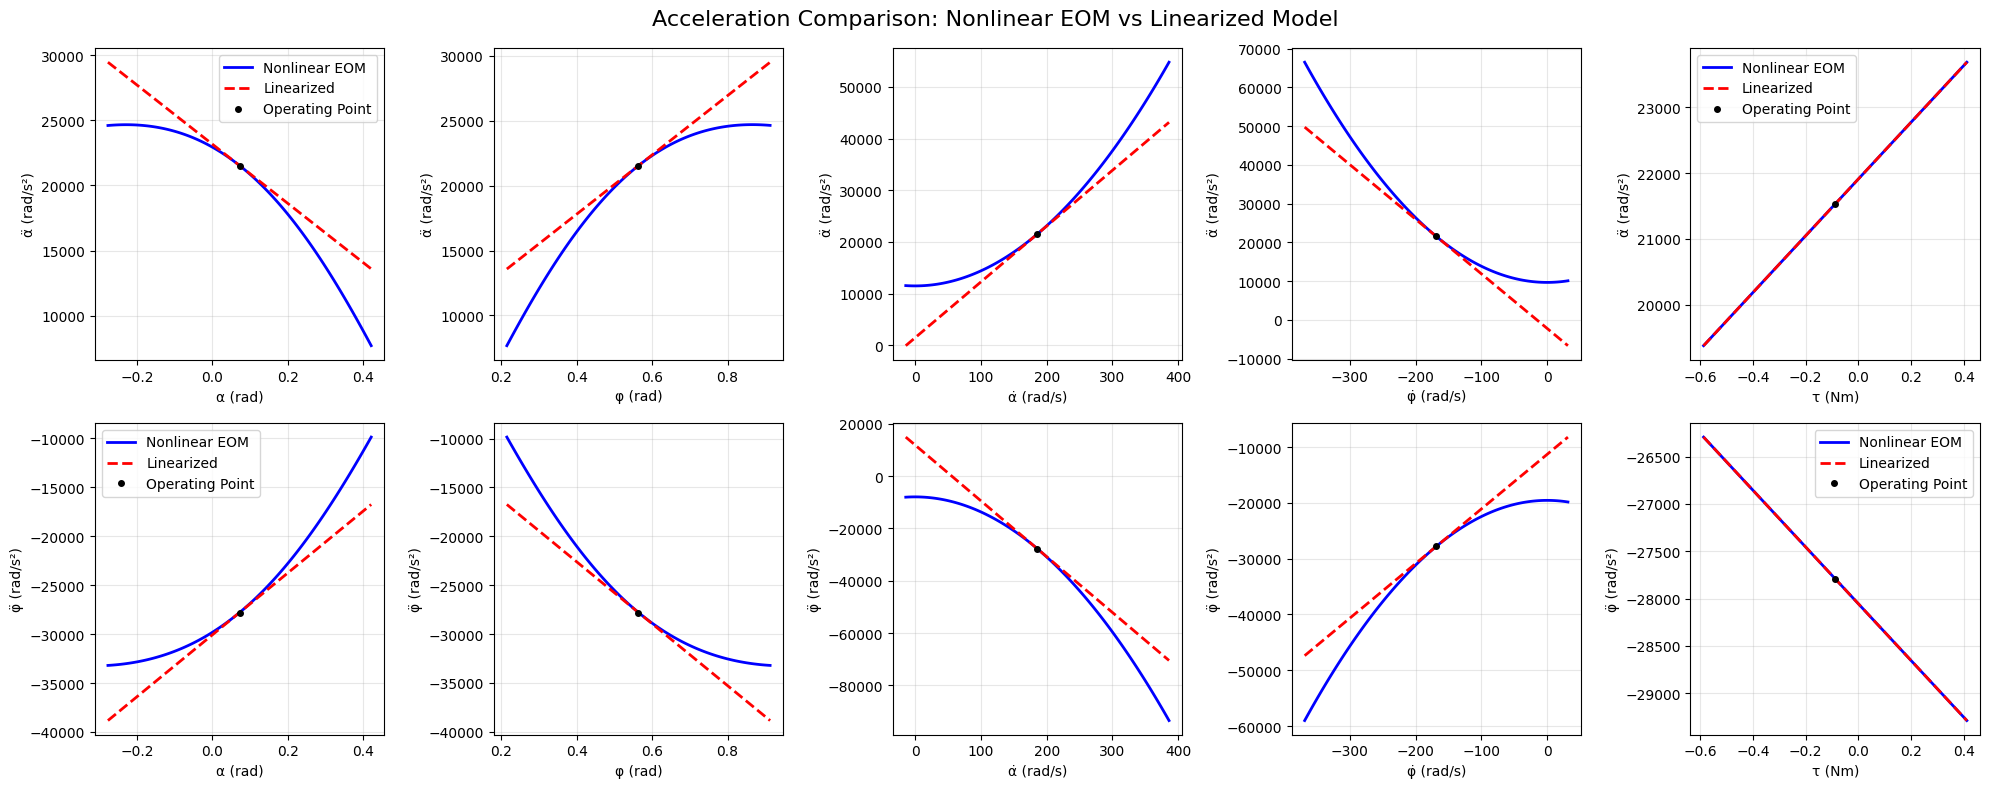

In [35]:

state_perturbations = [
    np.linspace(-delta_angle, delta_angle, 100),
    np.linspace(-delta_angle, delta_angle, 100),
    np.linspace(-delta_angleD, delta_angleD, 100),
    np.linspace(-delta_angleD, delta_angleD, 100)
]
torque_perturbations = np.linspace(-delta_torque, delta_torque, 100)

print("Operating point:", operating_point)
print("Operating torque:", torque)

# Create figure with 5 columns (4 states + 1 torque)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Acceleration Comparison: Nonlinear EOM vs Linearized Model', fontsize=16)

# Calculate operating point derivatives and linearization matrices
operating_point_dot = eom(operating_point, torque)
state_names = ['α (rad)', 'φ (rad)', 'α̇ (rad/s)', 'φ̇ (rad/s)', 'τ (Nm)']
accel_names = ['α̈', 'φ̈']

A_op = A_func(*operating_point)
B_op = B_func(*operating_point)

# Plot state perturbations (first 4 columns)
for state_ix in range(4):
    for accel_ix in range(2):
        op_accel = operating_point_dot[2 + accel_ix]
        ax = axes[accel_ix, state_ix]
        
        nonlinear_accels = []
        linear_accels = []
        perturbation_range = state_perturbations[state_ix]
        
        for perturbation in perturbation_range:
            perturbed_state = operating_point.copy()
            perturbed_state[state_ix] += perturbation
            
            # Calculating nonlinear accelerations
            nonlinear_result = eom(perturbed_state, torque)
            nonlinear_accel = nonlinear_result[2 + accel_ix]
            nonlinear_accels.append(nonlinear_accel)
            
            # Calculating linearized accelerations
            delta_state = np.zeros(4)
            delta_state[state_ix] += perturbation
            delta_accel = (A_op @ delta_state)[2 + accel_ix]
            linear_accel = delta_accel + op_accel
            linear_accels.append(linear_accel)
        
        perturbed_values = operating_point[state_ix] + perturbation_range
        ax.plot(perturbed_values, nonlinear_accels, 'b-', linewidth=2, label='Nonlinear EOM')
        ax.plot(perturbed_values, linear_accels, 'r--', linewidth=2, label='Linearized')
        ax.plot(operating_point[state_ix], op_accel, 'ko', markersize=4, label='Operating Point')
        ax.set_xlabel(state_names[state_ix])
        ax.set_ylabel(f'{accel_names[accel_ix]} (rad/s²)')
        ax.grid(True, alpha=0.3)
        if state_ix == 0:  # Only show legend on first column to avoid clutter
            ax.legend()

# Plot torque perturbations (5th column)
for accel_ix in range(2):
    op_accel = operating_point_dot[2 + accel_ix]
    ax = axes[accel_ix, 4]  # 5th column (index 4)
    
    nonlinear_accels = []
    linear_accels = []
    
    for torque_pert in torque_perturbations:
        perturbed_torque = torque + torque_pert
        
        # Calculating nonlinear accelerations
        nonlinear_result = eom(operating_point, perturbed_torque)
        nonlinear_accel = nonlinear_result[2 + accel_ix]
        nonlinear_accels.append(nonlinear_accel)
        
        # Calculating linearized accelerations
        delta_torque = torque_pert
        delta_accel = (B_op * delta_torque)[2 + accel_ix]
        linear_accel = delta_accel + op_accel
        linear_accels.append(linear_accel)
    
    perturbed_torques = torque + torque_perturbations
    ax.plot(perturbed_torques, nonlinear_accels, 'b-', linewidth=2, label='Nonlinear EOM')
    ax.plot(perturbed_torques, linear_accels, 'r--', linewidth=2, label='Linearized')
    ax.plot(torque, op_accel, 'ko', markersize=4, label='Operating Point')
    ax.set_xlabel(state_names[4])  # 'τ (Nm)'
    ax.set_ylabel(f'{accel_names[accel_ix]} (rad/s²)')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Summary
The linearized model closely matches the nonlinear equations of motion for small perturbations around the operating point, confirming the correctness of the Lagrangian derivation and linearization procedure.